In [1]:
# Import libraries

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Date & Time
from datetime import datetime

In [3]:
# Load dataset

df = pd.read_csv('traffic.csv')

# Show first 5 rows
df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
1,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8


In [4]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print(df.columns)

# Dataset info
df.info()

Dataset Shape: (226278, 9)
Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226278 entries, 0 to 226277
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   event    226278 non-null  object
 1   date     226278 non-null  object
 2   country  226267 non-null  object
 3   city     226267 non-null  object
 4   artist   226241 non-null  object
 5   album    226273 non-null  object
 6   track    226273 non-null  object
 7   isrc     219157 non-null  object
 8   linkid   226278 non-null  object
dtypes: object(9)
memory usage: 15.5+ MB


In [6]:
# Missing values

df.isnull().sum()

,0
event,0
date,0
country,11
city,11
artist,37
album,5
track,5
isrc,7121
linkid,0


In [7]:
# Remove duplicates

df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [9]:
print(df.columns)

Index(['event', 'date', 'country', 'city', 'artist', 'album', 'track', 'isrc',
       'linkid'],
      dtype='object')


In [13]:
# Convert date column into datetime format

df['date'] = pd.to_datetime(df['date'])

df.head()

,event,date,country,city,artist,album,track,isrc,linkid
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02


In [14]:
# Extract day, month and year

df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

df.head()

,event,date,country,city,artist,album,track,isrc,linkid,day,month,year
0,click,2021-08-21,Saudi Arabia,Jeddah,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,21,8,2021
2,click,2021-08-21,India,Ludhiana,Reyanna Maria,So Pretty,So Pretty,USUM72100871,23199824-9cf5-4b98-942a-34965c3b0cc2,21,8,2021
3,click,2021-08-21,France,Unknown,"Simone & Simaria, Sebastian Yatra",No Llores Más,No Llores Más,BRUM72003904,35573248-4e49-47c7-af80-08a960fa74cd,21,8,2021
4,click,2021-08-21,Maldives,Malé,Tesher,Jalebi Baby,Jalebi Baby,QZNWQ2070741,2d896d31-97b6-4869-967b-1c5fb9cd4bb8,21,8,2021
5,click,2021-08-21,United States,Los Angeles,KenTheMan,I'm Perfect,I'm Perfect,US39N2102090,190c7170-4044-4c97-9709-926917155b02,21,8,2021


In [15]:
# Total website events

print("Total Events:", len(df))

Total Events: 122567


In [16]:
top_countries = df['country'].value_counts().head(10)

print(top_countries)

country
United States     28664
India             18689
France            10565
Saudi Arabia       7682
United Kingdom     5095
Germany            4017
Canada             2784
Pakistan           2633
Iraq               2444
Turkey             2399
Name: count, dtype: int64


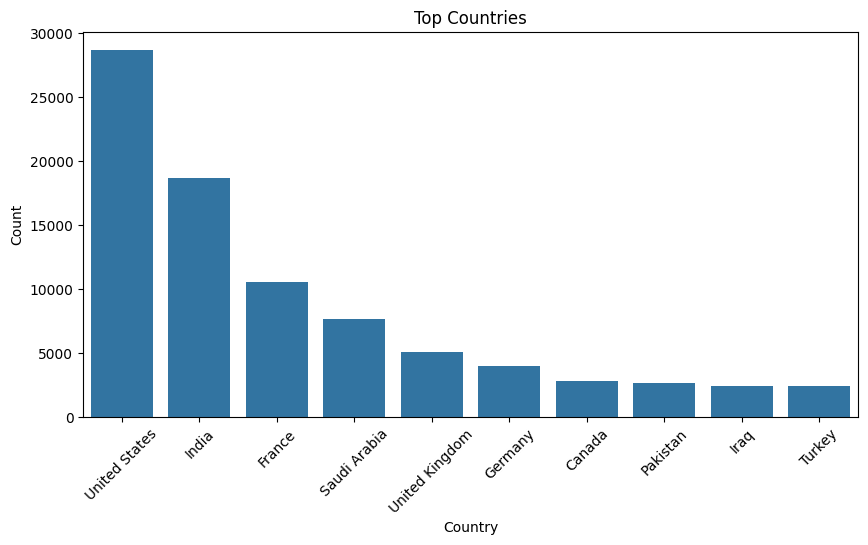

In [17]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_countries.index,
    y=top_countries.values
)

plt.title('Top Countries')
plt.xlabel('Country')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

In [18]:
top_cities = df['city'].value_counts().head(10)

print(top_cities)

city
Unknown        8797
Jeddah         2497
Riyadh         2232
Hyderabad      1088
Dammam         1002
Delhi           884
Jaipur          849
Lucknow         837
Kuwait City     816
Ahmedabad       808
Name: count, dtype: int64


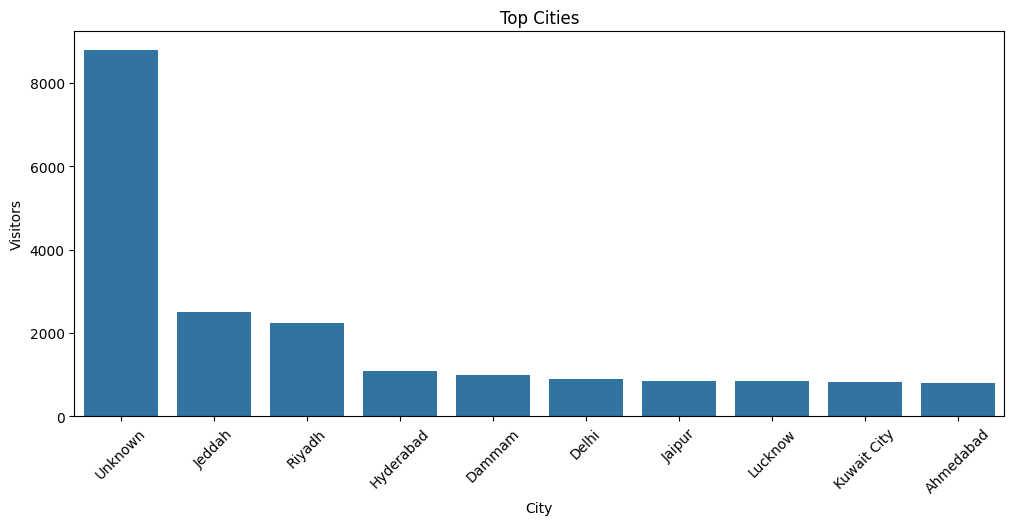

In [19]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=top_cities.index,
    y=top_cities.values
)

plt.title('Top Cities')
plt.xlabel('City')
plt.ylabel('Visitors')

plt.xticks(rotation=45)

plt.show()

In [20]:
top_artists = df['artist'].value_counts().head(10)

print(top_artists)

artist
Tesher                                                          8288
Anne-Marie                                                      4029
Tundra Beats                                                    3951
Roddy Ricch                                                     3107
Olivia Rodrigo                                                  3037
Surf Mesa, Emilee                                               2956
DMNDS, Strange Fruits Music, Fallen Roses, Lujavo, Nito-Onna    2865
Reyanna Maria                                                   2675
PinkPantheress                                                  2446
50 Cent, Olivia                                                 2390
Name: count, dtype: int64


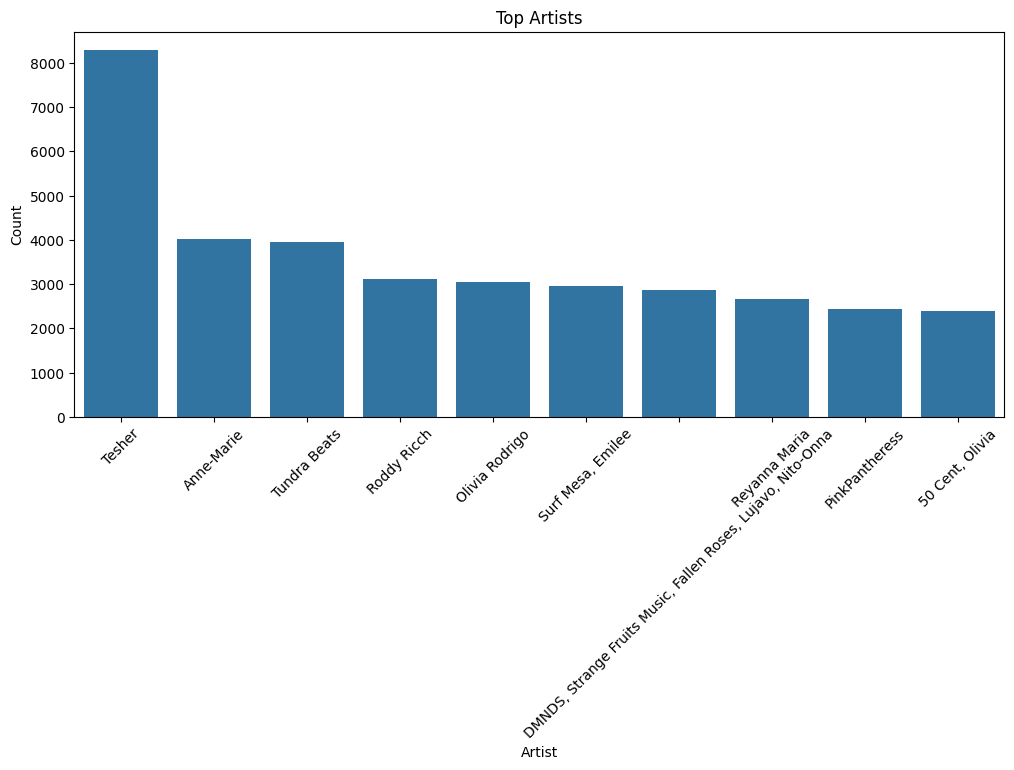

In [21]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=top_artists.index,
    y=top_artists.values
)

plt.title('Top Artists')
plt.xlabel('Artist')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

In [22]:
top_albums = df['album'].value_counts().head(10)

print(top_albums)

album
Jalebi Baby                             8288
Beautiful                               4028
Beautiful Day                           3950
Late At Night                           3059
ily (i love you baby) (feat. Emilee)    2956
SOUR                                    2878
The Massacre                            2870
Calabria (feat. Lujavo & Nito-Onna)     2865
So Pretty                               2830
Summer Of Love                          2108
Name: count, dtype: int64


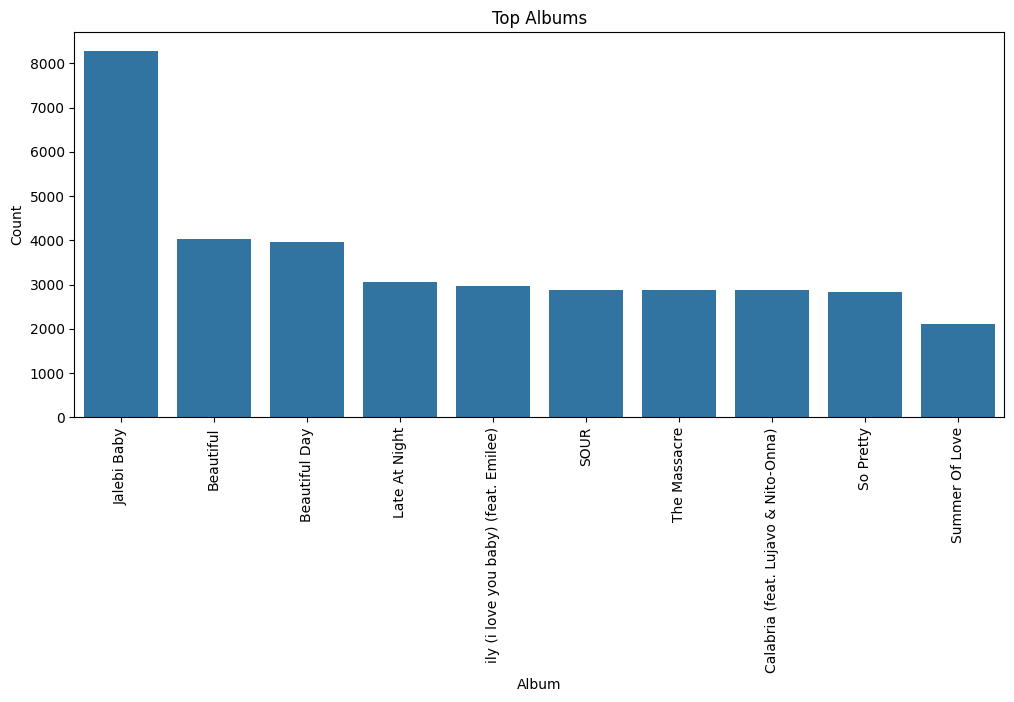

In [23]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=top_albums.index,
    y=top_albums.values
)

plt.title('Top Albums')
plt.xlabel('Album')
plt.ylabel('Count')

plt.xticks(rotation=90)

plt.show()

In [24]:
top_tracks = df['track'].value_counts().head(10)

print(top_tracks)

track
Jalebi Baby                              8288
Beautiful                                4037
Beautiful Day                            3951
Late At Night                            3059
ily (i love you baby) (feat. Emilee)     2956
Calabria (feat. Lujavo & Nito-Onna)      2865
So Pretty                                2830
Candy Shop                               2397
Summer of Love (Shawn Mendes & Tainy)    2108
Build a Bitch                            2072
Name: count, dtype: int64


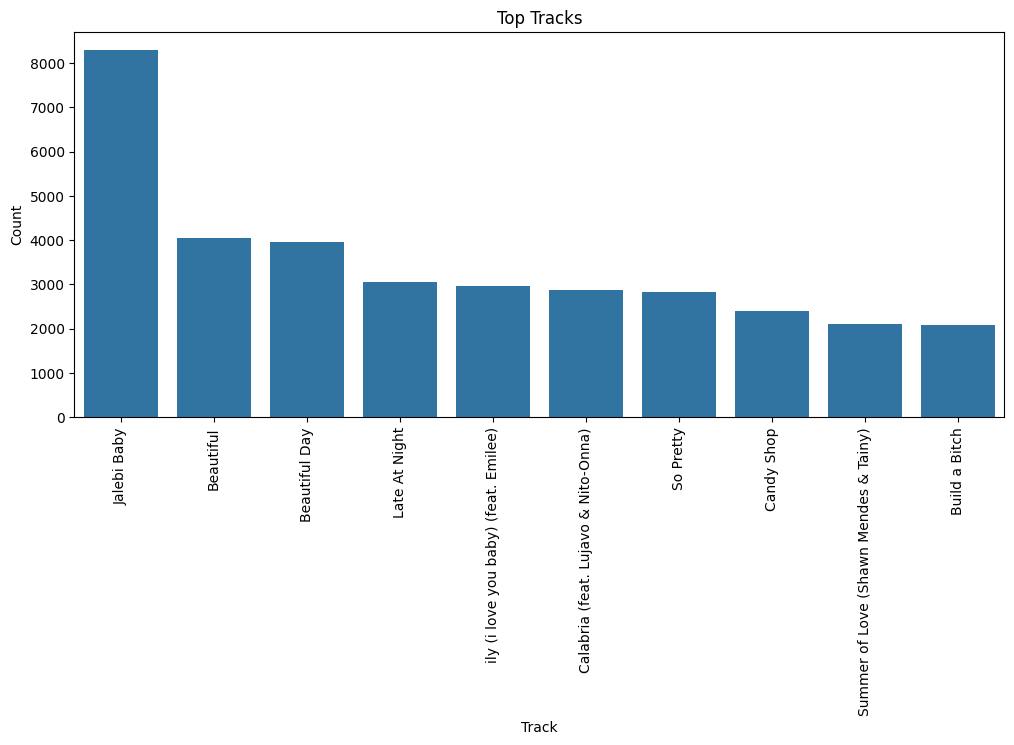

In [25]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=top_tracks.index,
    y=top_tracks.values
)

plt.title('Top Tracks')
plt.xlabel('Track')
plt.ylabel('Count')

plt.xticks(rotation=90)

plt.show()

In [26]:
daily_traffic = df.groupby('date').size()

print(daily_traffic.head())

date
2021-08-19    21156
2021-08-20    18536
2021-08-21    16701
2021-08-22    16927
2021-08-23    16415
dtype: int64


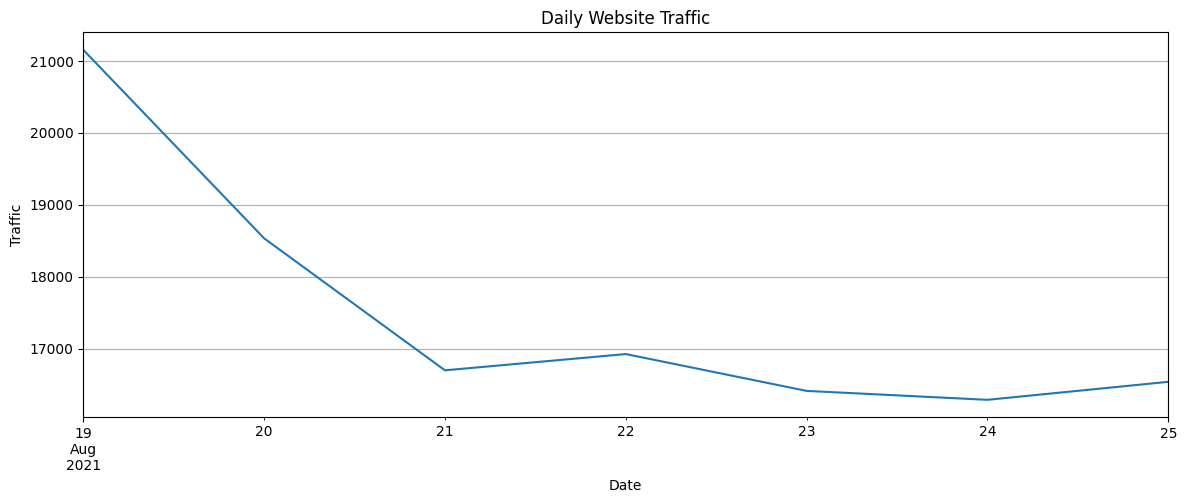

In [27]:
plt.figure(figsize=(14,5))

daily_traffic.plot()

plt.title('Daily Website Traffic')
plt.xlabel('Date')
plt.ylabel('Traffic')

plt.grid(True)

plt.show()

In [28]:
country_users = df.groupby('country')['linkid'].nunique().sort_values(ascending=False).head(10)

print(country_users)

country
United States     2895
Saudi Arabia       455
Canada             448
India              408
France             361
United Kingdom     312
Germany            283
Turkey             242
Pakistan           237
Iraq               230
Name: linkid, dtype: int64


In [29]:
event_counts = df['event'].value_counts()

print(event_counts)

event
pageview    73360
click       32499
preview     16708
Name: count, dtype: int64


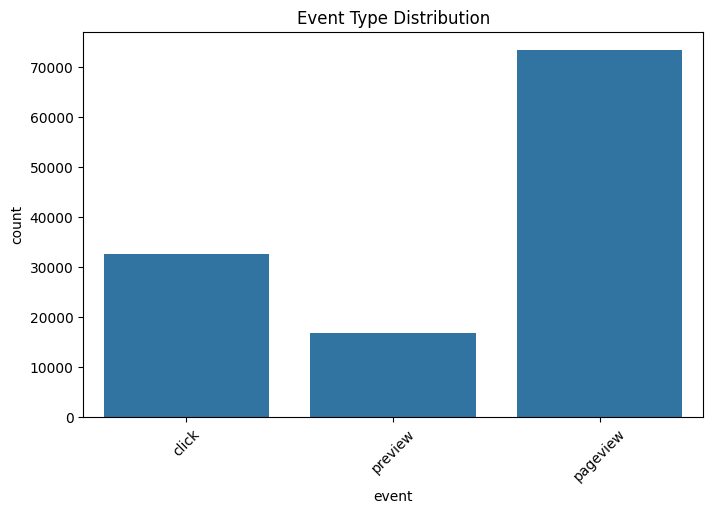

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(x='event', data=df)

plt.title('Event Type Distribution')

plt.xticks(rotation=45)

plt.show()